# LIBRARIES IMPORTATION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option("display.max.column", 20)
# Display revenue values in full
pd.options.display.float_format = '{:,.0f}'.format

In [3]:
customer = pd.read_csv(r"C:\Users\DELL\OIBSIP\DataAnalytics-L1-EDARetailSales\customers.csv")

In [4]:
customer.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,"29,158",4/25/2024,NaN
1,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,"16,862",5/30/2021,in-store
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,"21,918",12/14/2023,online
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,"52,851",7/11/2022,both
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,Jane Ferrell,32,Female,jane.ferrell@hotmail.com,5484281489,845 Kelly Estate,Atlanta,Georgia,"59,971",9/6/2020,online


In [5]:
cus_df = customer.copy()

In [6]:
cus_df.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,"29,158",4/25/2024,NaN
1,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,"16,862",5/30/2021,in-store
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,"21,918",12/14/2023,online
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,"52,851",7/11/2022,both
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,Jane Ferrell,32,Female,jane.ferrell@hotmail.com,5484281489,845 Kelly Estate,Atlanta,Georgia,"59,971",9/6/2020,online


In [7]:
cus_df.shape

(5000, 12)

In [8]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   object 
 1   full_name          4894 non-null   object 
 2   age                4814 non-null   float64
 3   gender             4888 non-null   object 
 4   email              4889 non-null   object 
 5   phone              4814 non-null   object 
 6   street_address     4823 non-null   object 
 7   city               4903 non-null   object 
 8   state              4907 non-null   object 
 9   zip_code           4904 non-null   float64
 10  registration_date  5000 non-null   object 
 11  preferred_channel  4886 non-null   object 
dtypes: float64(2), object(10)
memory usage: 468.9+ KB


After checking details about this dataset, here is what i identified:
1. There are 5,000 enteries and 12 columns.
2. There are missing values in about 10 columns except from customer_id and preferred_channel column.  
3. Mismatched datatype in age, zip code and registration_date columns. Age is an object instead of an integer, registration_date is an object but it's supposed to be a datetime datatype, zip code is suppose to be a string.

# Data Cleaning

In [9]:
duplicate_values = cus_df.duplicated().sum()
duplicate_values

0

In [10]:
missing_values = cus_df.isna().sum()
missing_values

customer_id            0
full_name            106
age                  186
gender               112
email                111
phone                186
street_address       177
city                  97
state                 93
zip_code              96
registration_date      0
preferred_channel    114
dtype: int64

In [11]:
# Dropping the columns that won't be needed for analysis
cus_df.drop(columns = ["full_name", "email", "street_address", "zip_code", "registration_date"], inplace = True)

In [12]:
cus_df["age"].describe()

count   4,814
mean       35
std        11
min        18
25%        27
50%        35
75%        42
max        80
Name: age, dtype: float64

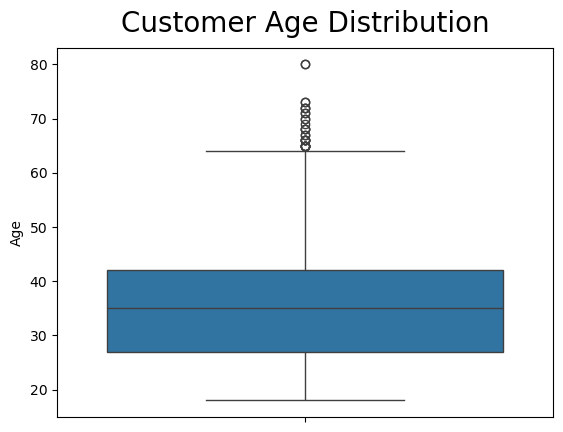

In [13]:
g = sns.boxplot(y = "age", data = cus_df)
g.set_title("Customer Age Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Age")
plt.show()

Filling missing values with median, since there are outliers and the data is skewed because median don't have an effect on extreme values.

In [14]:
cus_df["age"].fillna(cus_df["age"].median(), inplace = True)

In [15]:
cus_df["age"] = cus_df["age"].astype("int64")

In [16]:
cus_df["gender"].value_counts()

gender
Female               2413
Male                 2297
Non-binary            125
Prefer not to say      53
Name: count, dtype: int64

In [17]:
cus_df["gender"].fillna("Unknown", inplace = True)

In [18]:
cus_df["city"].unique()

array(['Houston', 'Austin', 'Detroit', 'Fort Worth', 'Atlanta',
       'San Francisco', 'Tempe', 'Tucson', 'New York City', 'Syracuse',
       'Columbus', 'Seattle', 'Macon', 'Arlington', 'Sacramento',
       'Champaign', 'Miami', 'Springfield', 'Toledo', 'Richmond',
       'Orlando', 'Phoenix', 'Trenton', 'Buffalo', 'Greensboro',
       'Rochester', 'Pittsburgh', 'Allentown', 'Savannah', 'Erie',
       'San Diego', 'Lowell', 'Virginia Beach', 'San Antonio',
       'Charlotte', 'Cincinnati', 'Vancouver', 'Philadelphia', 'Albany',
       'Tallahassee', 'Grand Rapids', 'Newark', 'Elizabeth', 'Flint',
       'Tampa', 'Jacksonville', 'Norfolk', 'Lansing', 'Chicago',
       'Los Angeles', 'Harrisburg', 'San Jose', 'Raleigh', 'Alexandria',
       'Tacoma', 'Augusta', 'Mesa', 'Worcester', 'Cambridge', 'Dallas',
       nan, 'Scottsdale', 'Bellevue', 'Spokane', 'Peoria', 'Rockford',
       'Ann Arbor', 'Athens', 'Durham', 'Akron', 'Cleveland',
       'Winston-Salem', 'Boston', 'Paterson', 'Jers

In [19]:
cus_df["city"].fillna("Unknown", inplace = True)

In [20]:
cus_df["state"].unique()

array(['Texas', 'Michigan', 'Georgia', 'California', 'Arizona',
       'New York', 'Ohio', 'Washington', 'Virginia', 'Illinois',
       'Florida', 'Massachusetts', 'New Jersey', 'North Carolina',
       'Pennsylvania', nan], dtype=object)

In [21]:
cus_df["state"].value_counts()

state
California        873
Texas             644
Florida           542
New York          469
Illinois          294
Pennsylvania      294
Ohio              258
Georgia           247
North Carolina    226
Michigan          208
Virginia          198
New Jersey        172
Washington        166
Arizona           159
Massachusetts     157
Name: count, dtype: int64

In [22]:
cus_df["state"].fillna("California", inplace = True)

In [23]:
cus_df["preferred_channel"].unique()

array([nan, 'in-store', 'online', 'both'], dtype=object)

In [24]:
cus_df["preferred_channel"].value_counts(normalize = True)

preferred_channel
online     1
both       0
in-store   0
Name: proportion, dtype: float64

In [25]:
cus_df["preferred_channel"].value_counts()

preferred_channel
online      2473
both        1457
in-store     956
Name: count, dtype: int64

In [26]:
cus_df["preferred_channel"].fillna("Unknown", inplace = True)

In [27]:
# First convert phone number to a string.
cus_df["phone"] = cus_df["phone"].astype("string")

In [28]:
# Extract extension
cus_df['extension'] = cus_df['phone'].str.extract(r'[xX](\d+)', expand = False)

In [29]:
# Remove extension
cus_df['phone_clean'] = cus_df['phone'].str.replace(r'[xX]\d+', '', regex = True)

In [30]:
# Remove brackets, spaces, dots, hyphens, +
cus_df['phone_clean'] = cus_df['phone_clean'].str.replace(r'\D', '', regex = True)

In [31]:
# Turn empty strings into missing values
cus_df['phone_clean'] = cus_df['phone_clean'].replace('', pd.NA)

In [32]:
# Validate standard 10-digit numbers
cus_df['phone_valid'] = cus_df['phone_clean'].str.fullmatch(r'\d{10}')

In [33]:
# Handle 11-digit numbers beginning with 1
cus_df.loc[
    cus_df['phone_clean'].str.fullmatch(r'1\d{10}', na = False), 'phone_clean'] = cus_df['phone_clean'].str[1:]

In [34]:
# Handle 13-digit numbers beginning with 001
cus_df.loc[
    cus_df['phone_clean'].str.fullmatch(r'001\d{10}', na = False),'phone_clean'] = cus_df['phone_clean'].str[3:]

In [35]:
# Anything that isn't exactly 10 digits becomes missing
cus_df.loc[
    ~cus_df['phone_clean'].str.fullmatch(r'\d{10}', na = False), 'phone_clean'] = pd.NA

In [36]:
cus_df['phone_clean'].str.len().value_counts(dropna = False)

phone_clean
10      4647
<NA>     353
Name: count, dtype: Int64

In [37]:
cus_df[cus_df['phone_clean'].isna()][['phone', 'phone_clean']]

,phone,phone_clean
7,<NA>,<NA>
37,-11121,<NA>
43,-7004,<NA>
51,<NA>,<NA>
61,<NA>,<NA>
...,...,...
4960,<NA>,<NA>
4962,-9879,<NA>
4967,-6859,<NA>
4984,-5584,<NA>


In [38]:
cus_df['phone_clean'] = cus_df['phone_clean'].str.replace(
    r'(\d{3})(\d{3})(\d{4})', r'\1-\2-\3', regex = True)

This code takes the values in the `phone_clean` column and **reformats 10-digit phone numbers into the `XXX-XXX-XXXX` format**. The regular expression `r'(\d{3})(\d{3})(\d{4})'` splits the phone number into three groups: the first 3 digits, the next 3 digits, and the final 4 digits. Then `r'\1-\2-\3'` puts those groups back together with hyphens between them. For example, `0801234567` would become `080-123-4567`. `regex=True` tells Pandas to treat the first argument as a regular expression.


In [39]:
cus_df['preferred_channel'] = cus_df['preferred_channel'].str.title()
# To convert values to proper case.

In [40]:
cus_df.head()

,customer_id,age,gender,phone,city,state,preferred_channel,extension,phone_clean,phone_valid
0,4c30e132-0704-4459-a509-9eddde934977,40,Male,989.608.3863,Houston,Texas,Unknown,<NA>,989-608-3863,True
1,68bec407-275f-4b5b-9a82-13d02f54626a,33,Male,(518)349-5931x0341,Austin,Texas,In-Store,0341,518-349-5931,True
2,4466459f-76c8-433c-814e-6d59cb4131fc,42,Female,364.583.5030x564,Detroit,Michigan,Online,564,364-583-5030,True
3,04c36a25-02f3-462c-92b0-6bf291c57706,53,Male,(332)887-1012x269,Fort Worth,Texas,Both,269,332-887-1012,True
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,32,Female,5484281489,Atlanta,Georgia,Online,<NA>,548-428-1489,True


In [41]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   object 
 1   age                5000 non-null   int64  
 2   gender             5000 non-null   object 
 3   phone              4814 non-null   string 
 4   city               5000 non-null   object 
 5   state              5000 non-null   object 
 6   preferred_channel  5000 non-null   object 
 7   extension          2889 non-null   string 
 8   phone_clean        4647 non-null   string 
 9   phone_valid        4814 non-null   boolean
dtypes: boolean(1), int64(1), object(5), string(3)
memory usage: 361.5+ KB


In [42]:
# Let drop phone number column, i only cleaned it because i want to learn how to clean phone number.
cus_df.drop(columns = ["phone", "phone_clean", "phone_valid", "extension"], inplace = True)

In [43]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5000 non-null   object
 1   age                5000 non-null   int64 
 2   gender             5000 non-null   object
 3   city               5000 non-null   object
 4   state              5000 non-null   object
 5   preferred_channel  5000 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [44]:
trans = pd.read_csv(r"C:\Users\DELL\OIBSIP\DataAnalytics-L1-EDARetailSales\transactions.csv")

In [45]:
trans_df = trans.copy()

In [46]:
trans_df.head()

,transaction_id,customer_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied
0,53e3d9f5-6231-46de-aa39-e5f8eaae2eee,727839b2-f084-4e94-94d8-ae59cc8e4b84,Ring Doorbell,Smart Home Devices,1,140,12/6/2020,"Houston, TX",Credit Card,20
1,ae6e6edf-f2fe-45c8-989c-c01e77eade0c,c4ac244c-989e-46fb-b243-91dd1d5cf739,Oculus Quest,Gaming Consoles,1,340,4/26/2021,Online,Gift Card,0
2,ba85240a-2b5d-4987-ac0a-efb6a4a57d6d,d296bf0d-92bb-4670-a578-2fd3553cf7c8,Samsung Galaxy S22,Smartphones,2,"1,336",10/28/2021,Online,PayPal,30
3,3725a285-2a2b-4a80-b317-7c8041cd9b8b,7b1b9980-9d65-40fc-8ad6-6afaae4699e4,External Hard Drive,Computer Accessories,1,92,3/16/2023,Online,Credit Card,25
4,de1b05a5-68c7-4b00-a068-e8c2f13f0dab,8595dcfa-2bfc-46f4-a15a-042af85b78cd,MacBook Pro,Laptops,1,985,8/30/2022,"Atlanta, GA",Credit Card,0


In [47]:
trans_df.shape

(32295, 10)

In [48]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32295 entries, 0 to 32294
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    32295 non-null  object 
 1   customer_id       32295 non-null  object 
 2   product_name      31617 non-null  object 
 3   product_category  31609 non-null  object 
 4   quantity          31651 non-null  float64
 5   price             31673 non-null  float64
 6   transaction_date  32295 non-null  object 
 7   store_location    31651 non-null  object 
 8   payment_method    31635 non-null  object 
 9   discount_applied  31684 non-null  float64
dtypes: float64(3), object(7)
memory usage: 2.5+ MB


In [49]:
trans_df.isna().sum()

transaction_id        0
customer_id           0
product_name        678
product_category    686
quantity            644
price               622
transaction_date      0
store_location      644
payment_method      660
discount_applied    611
dtype: int64

In [50]:
# Inspect this column
trans_df["product_name"].head(20)


0                Ring Doorbell
1                 Oculus Quest
2           Samsung Galaxy S22
3          External Hard Drive
4                  MacBook Pro
5                   Range Hood
6                   Range Hood
7        JBL Bluetooth Speaker
8                         Sofa
9                          NaN
10                   Air Fryer
11                    Area Rug
12                     Blender
13                    Wall Art
14                         NaN
15                 Google Nest
16                    Curtains
17    Audio-Technica Turntable
18             Nintendo Switch
19                  Table Lamp
Name: product_name, dtype: object

In [51]:
# Then check what other information is available in those rows with missing product name:
trans_df[trans_df["product_name"].isna()][
    ['product_category', 'quantity', 'price', 'store_location', 'payment_method', 'discount_applied']
].head(20)

,product_category,quantity,price,store_location,payment_method,discount_applied
9,Kitchen Appliances,1,"1,033",Online,Debit Card,10
14,Home Decor,2,313,Online,Credit Card,15
44,Smart Home Devices,2,NaN,Online,Credit Card,15
63,Home Decor,1,145,Online,Debit Card,0
68,Audio Equipment,1,203,Online,Google Pay,0
88,Audio Equipment,1,301,"Seattle, WA",Credit Card,5
155,Desktop Computers,1,"1,821",Online,Apple Pay,30
361,Audio Equipment,1,287,Online,Debit Card,0
463,Furniture,2,721,"Atlanta, GA",Cash,0
532,Smart Home Devices,2,143,NaN,Credit Card,0


In [52]:
# Checking whether the missing product category can be retrived from product name.
trans_df[trans_df['product_category'].isna()][['product_name']].head(20)

,product_name
17,Audio-Technica Turntable
36,Blender
48,Steam Deck
106,Wall Art
138,Asus ROG
163,iPhone 13
229,Xiaomi Mi 12
347,Wall Art
504,Cookware Set
587,Curtains


In [53]:
trans_df.groupby('product_name')['product_category'].agg(
    lambda x: x.dropna().unique()
).loc[['Audio-Technica Turntable', 'Blender', 'Steam Deck', 'Wall Art', 'Asus ROG', 
       'iPhone 13', 'Cookware Set', 'Dell XPS 15', 'Table Lamp', 'Dishwasher']]

product_name
Audio-Technica Turntable             [Audio Equipment]
Blender                     [Small Kitchen Appliances]
Steam Deck                           [Gaming Consoles]
Wall Art                                  [Home Decor]
Asus ROG                           [Desktop Computers]
iPhone 13                                [Smartphones]
Cookware Set                                [Cookware]
Dell XPS 15                                  [Laptops]
Table Lamp                                [Home Decor]
Dishwasher                        [Kitchen Appliances]
Name: product_category, dtype: object

In [54]:
category_map = trans_df.groupby('product_name')['product_category'].first()

trans_df['product_category'] = trans_df['product_category'].fillna(
    trans_df['product_name'].map(category_map))

In [55]:
trans_df['product_category'].isna().sum()

19

The product category that are still missing indicate that th product name is missing.

In [56]:
trans_df['quantity'].describe()

count   31,651
mean         1
std          2
min          1
25%          1
50%          1
75%          2
max         50
Name: quantity, dtype: float64

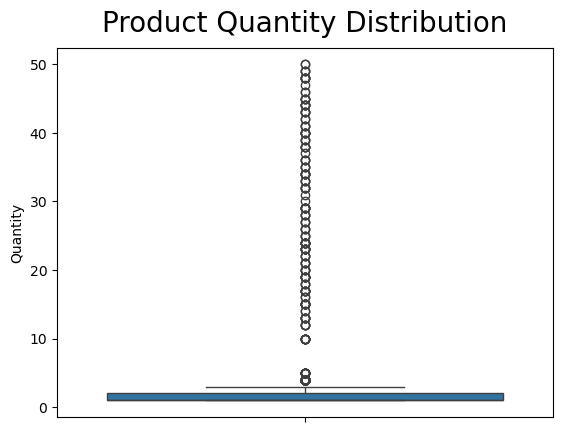

In [57]:
g = sns.boxplot(y = "quantity", data = trans_df)
g.set_title("Product Quantity Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Quantity")
plt.show()

In [58]:
trans_df["quantity"].fillna(trans_df["quantity"].median(), inplace = True)

I used the **median** because the quantity data is **skewed and contains extreme values**, such as 50. The median is less affected by these outliers than the mean.


In [59]:
trans_df["quantity"] = trans_df["quantity"].astype("int64")

In [60]:
trans_df["price"].describe()

count   31,673
mean       622
std        665
min         17
25%        180
50%        402
75%        877
max     21,372
Name: price, dtype: float64

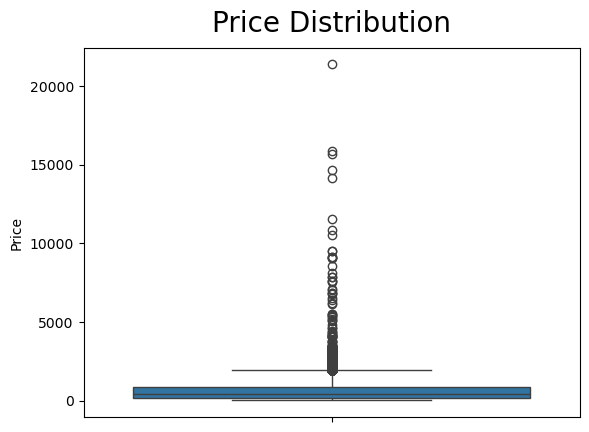

In [61]:
g = sns.boxplot(y = "price", data = trans_df)
g.set_title("Price Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Price")
plt.show()

In [62]:
trans_df["price"].fillna(trans_df["price"].median(), inplace = True)

In [63]:
trans_df['discount_applied'].describe()

count   31,684
mean         5
std          9
min          0
25%          0
50%          0
75%         10
max         30
Name: discount_applied, dtype: float64

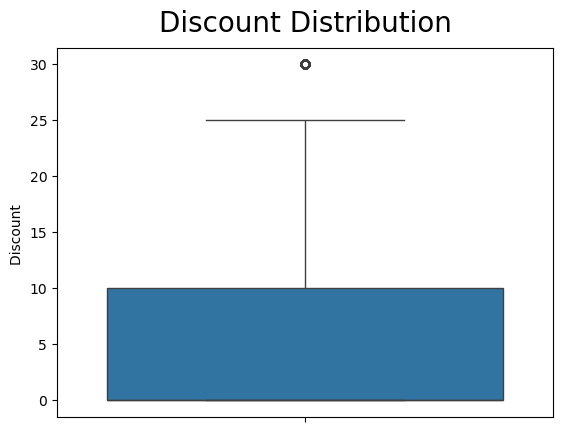

In [64]:
g = sns.boxplot(y = "discount_applied", data = trans_df)
g.set_title("Discount Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Discount ")
plt.show()

In [65]:
# I will be replacing NANs with 0 because it means there was no discount and 0 is actually the mean.
trans_df["discount_applied"].fillna(trans_df["discount_applied"].median(), inplace = True)

In [66]:
trans_df["discount_applied"] = trans_df["discount_applied"].astype("int64")

In [67]:
trans_df.isna().sum()

transaction_id        0
customer_id           0
product_name        678
product_category     19
quantity              0
price                 0
transaction_date      0
store_location      644
payment_method      660
discount_applied      0
dtype: int64

In [68]:
trans_df["store_location"].unique()

array(['Houston, TX', 'Online', 'Atlanta, GA', 'Boston, MA', 'Denver, CO',
       'Miami, FL', 'Chicago, IL', 'Seattle, WA', 'New York, NY',
       'San Francisco, CA', 'Los Angeles, CA', nan], dtype=object)

In [69]:
trans_df["store_location"].value_counts()

store_location
Online               16108
Houston, TX           1630
Miami, FL             1587
San Francisco, CA     1579
Atlanta, GA           1563
New York, NY          1562
Chicago, IL           1559
Seattle, WA           1536
Denver, CO            1529
Boston, MA            1528
Los Angeles, CA       1470
Name: count, dtype: int64

In [70]:
trans_df["store_location"].fillna("Unknown", inplace = True)

In [71]:
trans_df["payment_method"].fillna("Unknown", inplace = True)

In [72]:
trans_df = trans_df.dropna(subset = ['product_category'])

In [73]:
trans_df["product_name"].fillna("Unknown", inplace = True)

In [74]:
trans_df["transaction_date"] = pd.to_datetime(trans_df["transaction_date"], errors = "coerce")

In [75]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5000 non-null   object
 1   age                5000 non-null   int64 
 2   gender             5000 non-null   object
 3   city               5000 non-null   object
 4   state              5000 non-null   object
 5   preferred_channel  5000 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [76]:
cus_df.duplicated().sum()

0

In [77]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32276 entries, 0 to 32294
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    32276 non-null  object        
 1   customer_id       32276 non-null  object        
 2   product_name      32276 non-null  object        
 3   product_category  32276 non-null  object        
 4   quantity          32276 non-null  int64         
 5   price             32276 non-null  float64       
 6   transaction_date  32276 non-null  datetime64[ns]
 7   store_location    32276 non-null  object        
 8   payment_method    32276 non-null  object        
 9   discount_applied  32276 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 2.7+ MB


In [78]:
trans_df.duplicated().sum()

0

In [79]:
df = trans_df.merge(cus_df, on = "customer_id", how = "left")

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32276 entries, 0 to 32275
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     32276 non-null  object        
 1   customer_id        32276 non-null  object        
 2   product_name       32276 non-null  object        
 3   product_category   32276 non-null  object        
 4   quantity           32276 non-null  int64         
 5   price              32276 non-null  float64       
 6   transaction_date   32276 non-null  datetime64[ns]
 7   store_location     32276 non-null  object        
 8   payment_method     32276 non-null  object        
 9   discount_applied   32276 non-null  int64         
 10  age                32276 non-null  int64         
 11  gender             32276 non-null  object        
 12  city               32276 non-null  object        
 13  state              32276 non-null  object        
 14  prefer

In [81]:
df.isna().sum()

transaction_id       0
customer_id          0
product_name         0
product_category     0
quantity             0
price                0
transaction_date     0
store_location       0
payment_method       0
discount_applied     0
age                  0
gender               0
city                 0
state                0
preferred_channel    0
dtype: int64

In [82]:
df.duplicated().sum()

0

In [83]:
df["age"].unique()

array([33, 18, 40, 26, 31, 45, 22, 44, 51, 38, 70, 35, 23, 53, 27, 37, 25,
       32, 28, 41, 50, 30, 47, 49, 46, 54, 73, 48, 34, 24, 43, 19, 57, 36,
       42, 21, 52, 68, 39, 29, 56, 58, 20, 65, 55, 59, 63, 60, 61, 64, 67,
       66, 62, 71, 72, 80, 69], dtype=int64)

In [84]:
df["state"].unique()

array(['Florida', 'Texas', 'Virginia', 'Pennsylvania', 'California',
       'Arizona', 'Washington', 'Illinois', 'Ohio', 'Georgia',
       'New Jersey', 'Michigan', 'New York', 'North Carolina',
       'Massachusetts'], dtype=object)

In [85]:
df["payment_method"].unique()

array(['Credit Card', 'Gift Card', 'PayPal', 'Debit Card', 'Apple Pay',
       'Cash', 'Unknown', 'Google Pay'], dtype=object)

In [86]:
# Select numerical columns
num_cols = df.select_dtypes(include = 'number').columns
num_cols

Index(['quantity', 'price', 'discount_applied', 'age'], dtype='object')

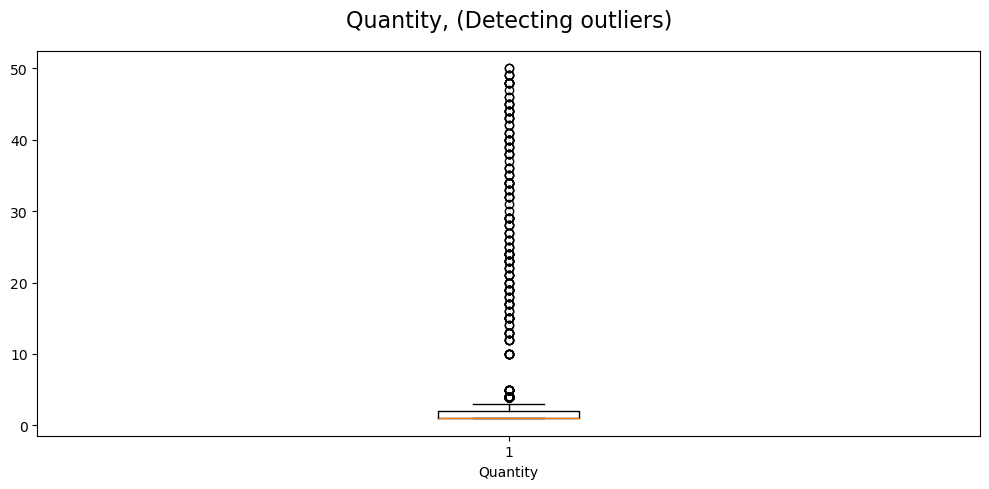

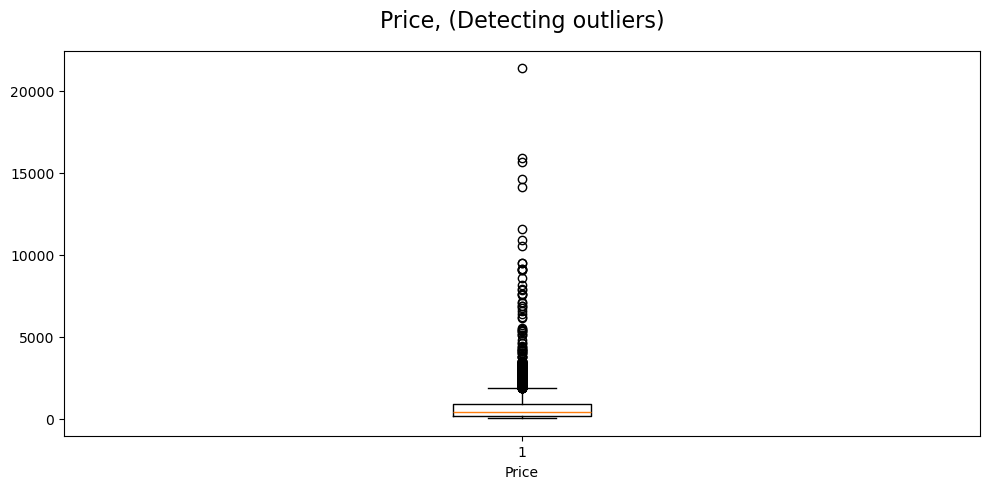

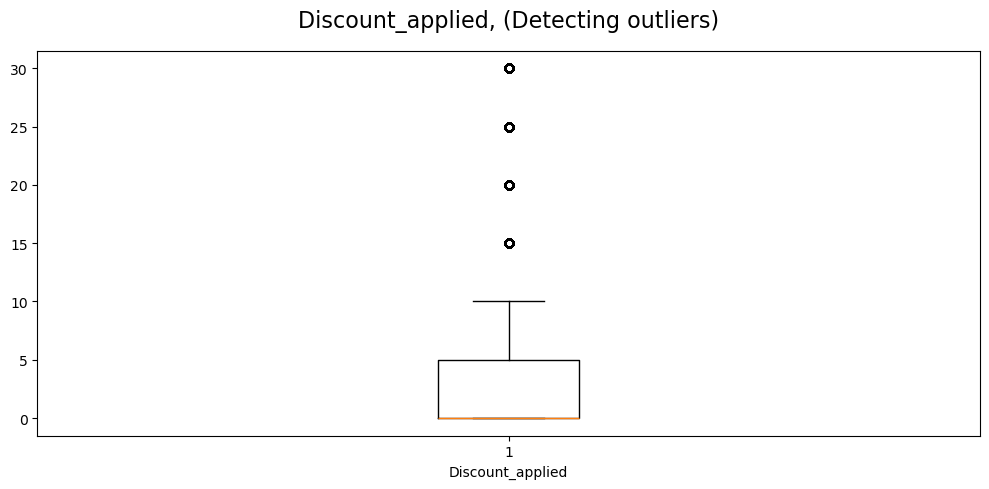

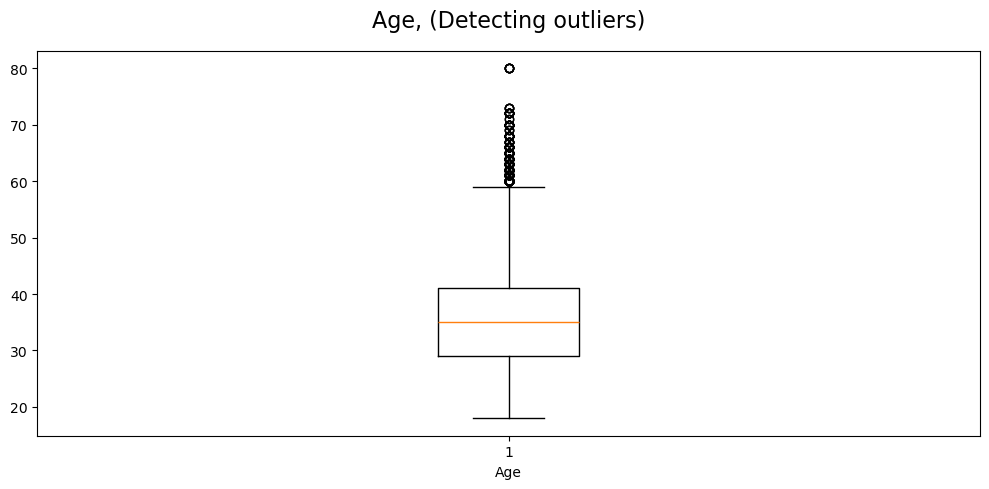

In [87]:
# Checking for outliers
for col in num_cols:
    plt.figure(figsize = (10, 5))
    plt.boxplot(x = df[col])
    plt.title(f'{col.capitalize()}, (Detecting outliers)', fontsize = 16, y = 1.04)
    plt.xlabel(col.capitalize())
    plt.tight_layout()
    plt.show()

In [88]:
df[['quantity', 'price', 'age', 'discount_applied']].describe()

,quantity,price,age,discount_applied
count,"32,276","32,276","32,276","32,276"
mean,1,618,35,5
std,2,659,10,9
min,1,17,18,0
25%,1,183,29,0
50%,1,402,35,0
75%,2,865,41,5
max,50,"21,372",80,30


In [89]:
for col in num_cols:
    df[col] = winsorize(df[col], limits = [0.05, 0.05])

Outlier Analysis: The descriptive statistics and boxplots revealed extreme values in Quantity, Price, and Age. For example, Quantity reaches a maximum of 50, while Price reaches 21,371.65. However, these observations were investigated and confirmed to represent legitimate values in the dataset rather than data-entry errors. Consequently, the outliers were retained to preserve the original characteristics of the data. The Discount Applied variable showed comparatively fewer extreme observations, with values ranging from 0 to 30.

In [90]:
df["revenue"] = df["quantity"] * df["price"]

In [91]:
df["year"] = df["transaction_date"].dt.year

In [92]:
df["month"] = df["transaction_date"].dt.month_name()

In [93]:
df["month"].unique()

array(['December', 'April', 'October', 'March', 'August', 'February',
       'January', 'June', 'November', 'July', 'May', 'September'],
      dtype=object)

In [94]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
df["month"] = pd.Categorical(df["month"], categories = month_order, ordered = True)

In [95]:
df["quarter"] = df["transaction_date"].dt.quarter
df["quarter"] = "Q" + df["quarter"].astype(str)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32276 entries, 0 to 32275
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     32276 non-null  object        
 1   customer_id        32276 non-null  object        
 2   product_name       32276 non-null  object        
 3   product_category   32276 non-null  object        
 4   quantity           32276 non-null  int64         
 5   price              32276 non-null  float64       
 6   transaction_date   32276 non-null  datetime64[ns]
 7   store_location     32276 non-null  object        
 8   payment_method     32276 non-null  object        
 9   discount_applied   32276 non-null  int64         
 10  age                32276 non-null  int64         
 11  gender             32276 non-null  object        
 12  city               32276 non-null  object        
 13  state              32276 non-null  object        
 14  prefer

# EDA

DESCRIPTIVE  STATISTICS

In [97]:
# Select numerical columns
num_cols = df.select_dtypes(include = 'number').columns
num_cols

Index(['quantity', 'price', 'discount_applied', 'age', 'revenue', 'year'], dtype='object')

In [98]:
summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode': [df[col].mode().iloc[0] for col in num_cols],
    'Standard Deviation': df[num_cols].std()
}, index = num_cols)

summary

,Mean,Median,Mode,Standard Deviation
quantity,1,1,1,0
price,590,402,61,524
discount_applied,5,0,0,9
age,35,35,35,9
revenue,742,475,"1,888",742
year,"2,023","2,023","2,024",1


Insight: The average quantity purchased is about 1.26, and most customers purchase 1 item, showing that customers generally make small purchases. The average price is 590.32, but the median price is lower at 401.70, suggesting that some expensive products are increasing the average. Most transactions have no discount, as both the median and mode are 0, although some customers receive higher discounts. The average customer age is about 35 years, with most customers being around this age. Coming from the price column, where some product are increasing the average, it does the same to the revenue.

TIME SERIES ANALYSIS

In [99]:
df["revenue"]

0         140
1         340
2       2,672
3          92
4         985
         ... 
32271     222
32272     402
32273     538
32274     231
32275     910
Name: revenue, Length: 32276, dtype: float64

In [100]:
yearly_sales = df.groupby("year")["revenue"].sum()
yearly_sales

year
2020     775,571
2021   2,547,350
2022   4,508,585
2023   6,551,796
2024   8,437,018
2025   1,143,145
Name: revenue, dtype: float64

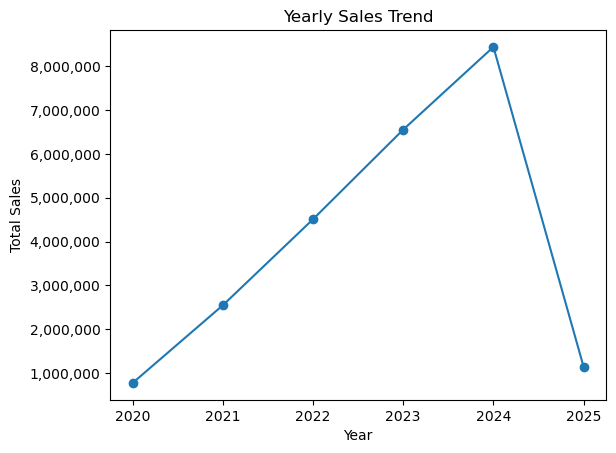

In [101]:
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Yearly Sales Trend')
# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)
plt.show()

In [102]:
monthly_sales = df.groupby("month", observed = True)["revenue"].sum()
monthly_sales

month
January     1,849,094
February    1,710,923
March       1,301,427
April       1,345,915
May         1,465,673
June        1,438,815
July        2,254,825
August      2,565,887
September   1,554,438
October     1,692,861
November    3,305,593
December    3,478,015
Name: revenue, dtype: float64

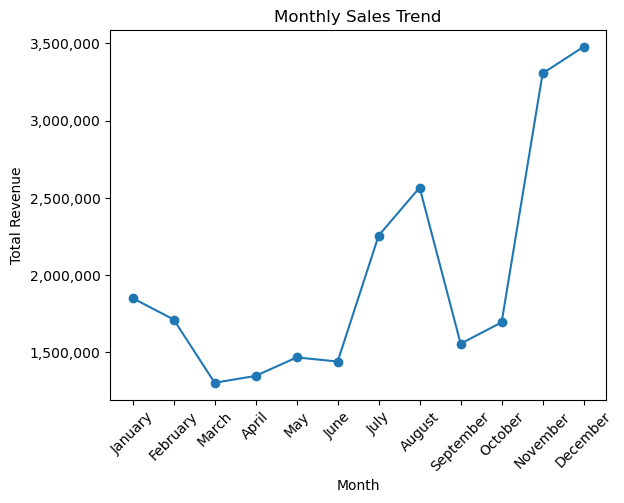

In [103]:
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)
plt.show()

In [104]:
quarterly_sales = df.groupby("quarter", observed = True)["revenue"].sum()
quarterly_sales

quarter
Q1   4,861,444
Q2   4,250,403
Q3   6,375,150
Q4   8,476,468
Name: revenue, dtype: float64

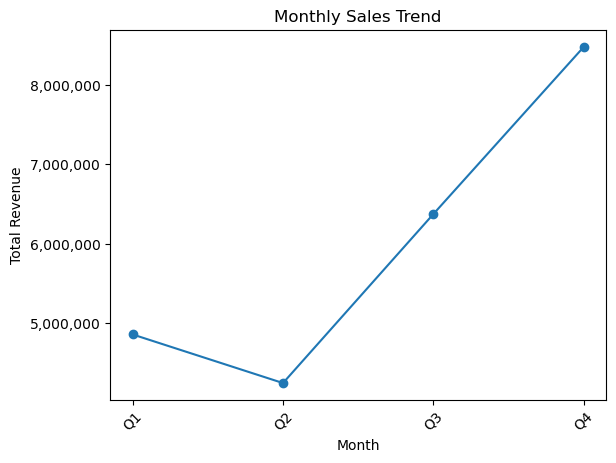

In [105]:
plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)
plt.show()

### Insight from Sales Trend

**Yearly:** Sales increased steadily from **775,571 in 2020** to **8,437,018 in 2024**, showing strong year-on-year growth. However, sales decreased to **1,143,145 in 2025**. This sharp decrease should be investigated further to determine whether it is due to lower sales or because the 2025 dataset does not cover the full year.

**Monthly:** Sales increased from **January to August**, followed by a decline in **September and October**. Sales then increased again in **November**, reaching **3,305,593**, and rose further in **December to 3,478,015**. This suggests stronger sales toward the end of the year.

**Quarterly:** Sales were relatively low during the **first and second quarters**. Sales increased in the **third quarter**, reaching **6,375,150**, and increased further in the **fourth quarter to 8,476,468**.

**Overall insight:** The fourth quarter generated the **highest sales**, suggesting that sales tend to be stronger toward the end of the year. This may indicate a possible seasonal pattern and could help the business plan inventory, marketing, and promotions for the final quarter.


CUSTOMER DEMOGRAPHICS

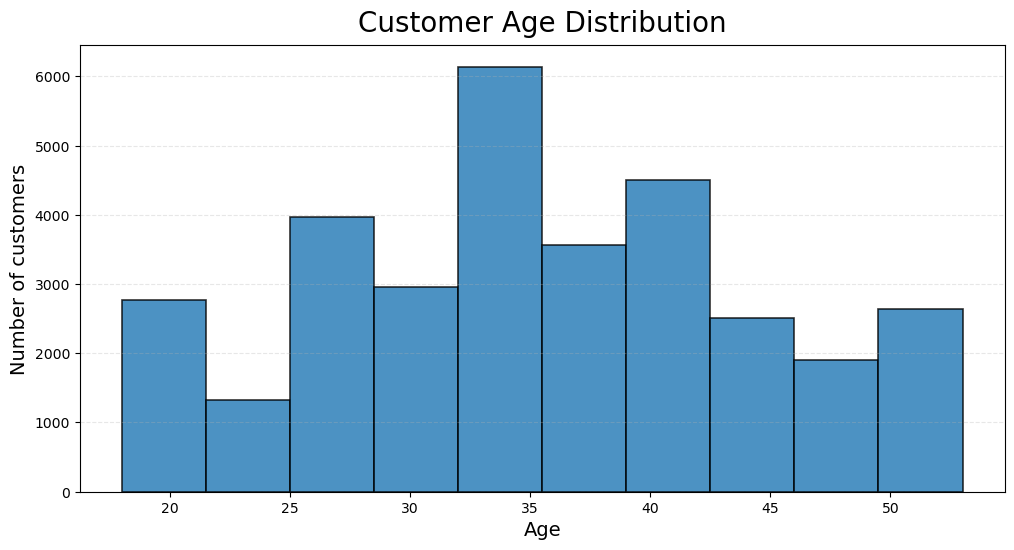

In [106]:
plt.figure(figsize = (10, 5))
plt.hist(df["age"], bins = 10, alpha = 0.8, edgecolor = "black", linewidth = 1.2)
plt.tight_layout()
plt.title("Customer Age Distribution", fontsize = 20, pad = 10)
plt.xlabel("Age", fontsize = 14)
plt.ylabel("Number of customers", fontsize = 14)
plt.grid(axis = "y", linestyle = "--", alpha = 0.3)
plt.show()

### Observation

The age distribution shows that most customers are around **35 years old**, indicating that the business has a strong customer base within the adult age range.


In [107]:
gender_counts = df["gender"].value_counts()

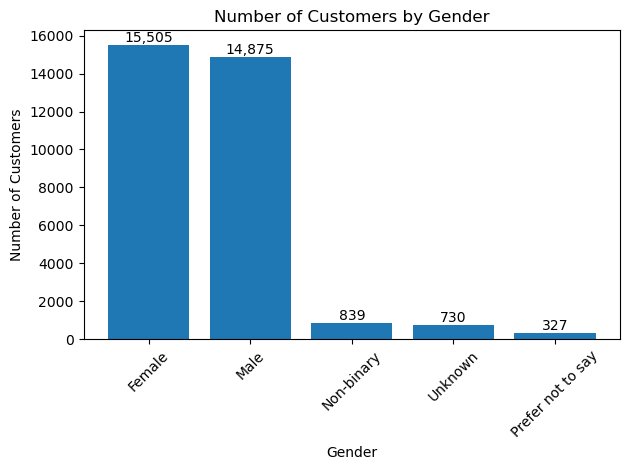

In [108]:
bars = plt.bar(gender_counts.index, gender_counts.values)
for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
        value, f"{int(value):,}", ha = "center", va = "bottom")
plt.title("Number of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Female customers make up the largest gender group, with **15,505 customers**, followed by males with **14,875 customers**. Non-binary, Unknown, and Prefer not to say customers represent relatively smaller groups.


In [109]:
bins = [0, 29, 59, 100]

labels = [
    "Young Adult",
    "Adult",
    "Older Adult"
]
df["age_group"] = pd.cut(df["age"], bins = bins, labels = labels, include_lowest = True)

In [110]:
age_group_counts = df["age_group"].value_counts()

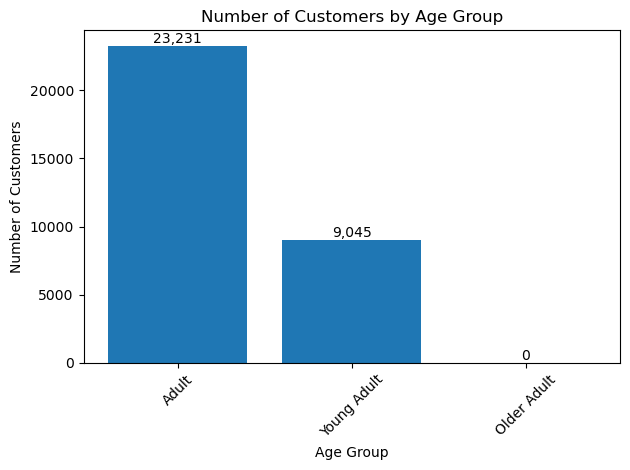

In [111]:
bars = plt.bar(age_group_counts.index, age_group_counts.values)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The **Adult group has the highest number of customers, with 23,231 records**, followed by Young Adults with 9,045 records. No customers were recorded in the Older Adult group, showing that the customer base is mainly concentrated among younger and middle-aged customers.


In [112]:
# Revenue by Gender
gender_revenue = df.groupby("gender")["revenue"].sum().sort_values(ascending=False)
gender_revenue

gender
Female              11,563,703
Male                10,995,130
Non-binary             641,899
Unknown                525,862
Prefer not to say      236,873
Name: revenue, dtype: float64

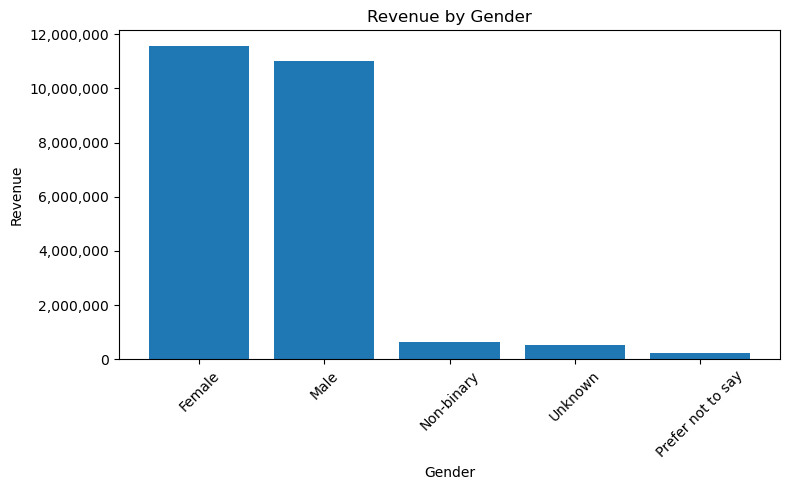

In [113]:
plt.figure(figsize=(8, 5))
plt.bar(gender_revenue.index, gender_revenue.values)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.tight_layout()
plt.show()

### Observation

Female customers generated the highest revenue at **11,563,703**, compared with **10,995,130** generated by male customers. This indicates that female customers currently contribute slightly more to overall sales.


In [114]:
# Revenue by Age group
age_group_revenue = df.groupby("age_group")["revenue"].sum().sort_values(ascending=False)
age_group_revenue

age_group
Adult         17,134,711
Young Adult    6,828,755
Older Adult            0
Name: revenue, dtype: float64

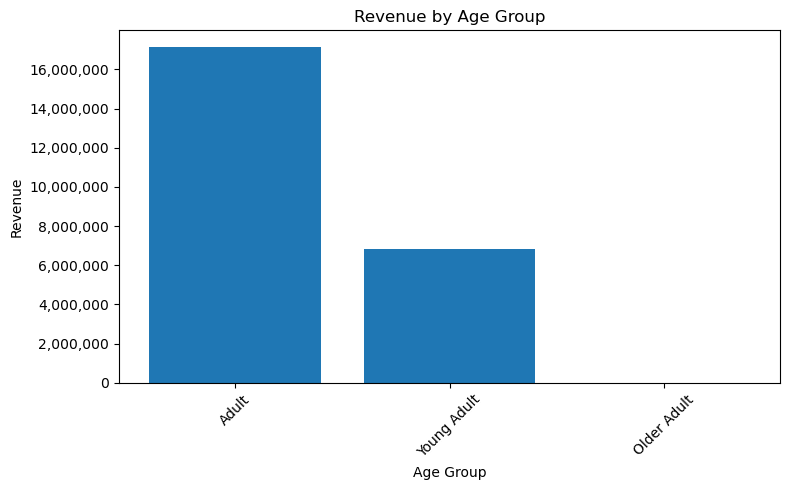

In [115]:
plt.figure(figsize=(8, 5))
plt.bar(age_group_revenue.index, age_group_revenue.values)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.tight_layout()
plt.show()

### Observation

The **Adult group generated the highest revenue at 17,134,711**, while Young Adults generated **6,828,755**. No revenue was recorded for the Older Adult group. This shows that **adults are the main revenue-generating customer segment**.


In [116]:
# Revenue by Age Group and Gender
age_gender_revenue = (
    df.groupby(["age_group", "gender"], observed=True)["revenue"].sum().unstack())
age_gender_revenue

gender,Female,Male,Non-binary,Prefer not to say,Unknown
age_group,,,,,
Young Adult,"3,330,828","3,060,116","174,197","90,816","172,798"
Adult,"8,232,875","7,935,014","467,701","146,056","353,065"


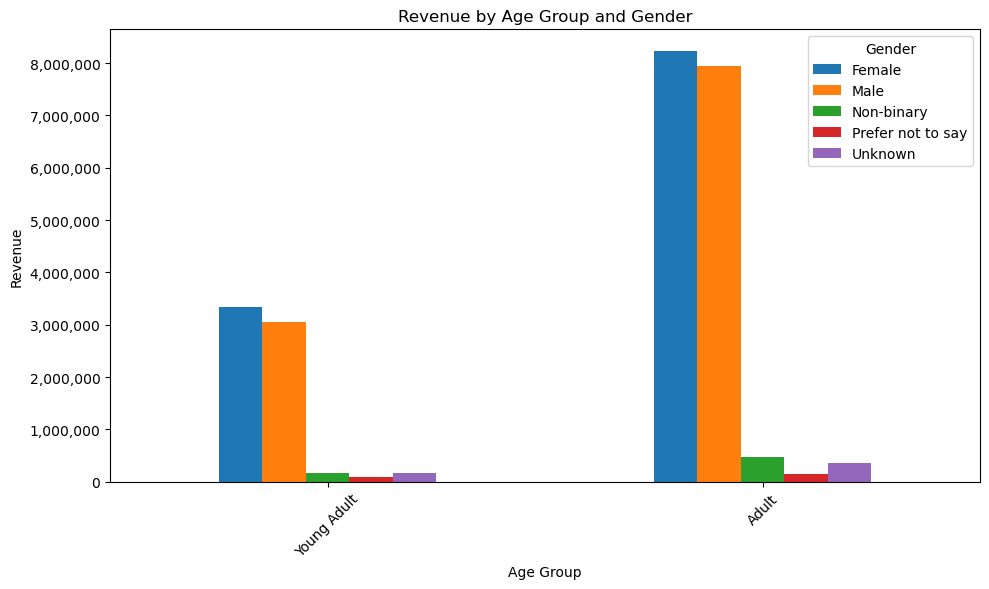

In [117]:
# Plot
ax = age_gender_revenue.plot(kind = "bar", figsize = (10, 6))

plt.title("Revenue by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Gender")

# Display full revenue values on Y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### Observation

The Adult group generated the highest revenue across all gender categories, with **female adults contributing the most at 8,232,875**, followed by male adults at **7,935,014**. Among Young Adults, females also generated the highest revenue at **3,330,828**. Overall, **adult female customers represent the strongest revenue-generating segment**.


## Conclusion

Based on the sales and customer analysis, the business is experiencing strong sales growth overall, with Q4 and the end-of-year period generating the highest sales. Adults are the largest customer group and also generate the highest revenue, while female customers contribute slightly more revenue than male customers.

Based on the sales and customer analysis, the following three recommendations can be made:

1. **Focus on Q4 sales opportunities:** Increase inventory, marketing, and promotions before Q4 because it records the highest sales.

2. **Target adult and female customers:** Prioritize these segments in marketing campaigns because adults generate the highest revenue and female customers contribute the most revenue.

3. **Investigate the 2025 sales decline:** Review the 2025 data to determine whether the decrease reflects an actual decline in sales or incomplete year coverage.
